# Employee Retention Model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             precision_recall_curve, f1_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('IBM-HR-Employee.csv')
print("Shape:", df.shape)



Shape: (1470, 35)


In [3]:
df.info()
df.head().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,Yes,No,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,1102,279,1373,1392,591
Department,Sales,Research & Development,Research & Development,Research & Development,Research & Development
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,Life Sciences,Life Sciences,Other,Life Sciences,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


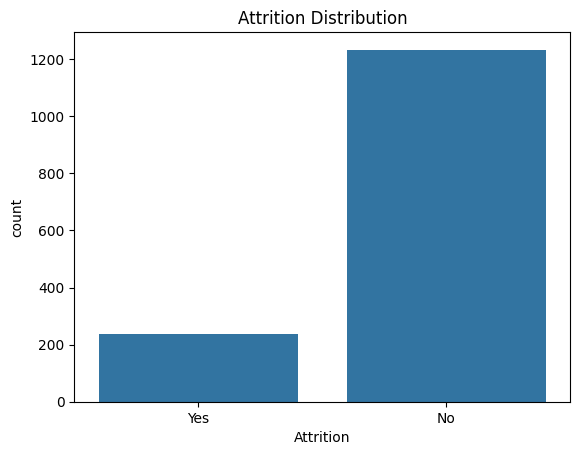

In [4]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

In [5]:
print("Attrition class balance:")
print(df['Attrition'].value_counts())
print()
print("Imbalance ratio:", round(df['Attrition'].value_counts()[0] / df['Attrition'].value_counts()[1], 2),
      ":1 (No:Yes)")


Attrition class balance:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Imbalance ratio: 5.2 :1 (No:Yes)


## 3. Feature Selection

Same logic as original — drop constant, ID, and redundant columns.  
We also **keep `EducationField`** (dropped in original) since it can weakly signal career path mobility.


In [6]:
drop_cols = ['EmployeeNumber', 'Education', 'JobLevel', 'Gender', 'Department',
             'HourlyRate', 'DailyRate', 'MonthlyRate', 'EmployeeCount',
             'Over18', 'StandardHours','EducationField']

df_feat = df.drop(columns=drop_cols)
print("Remaining columns:", df_feat.shape[1])
df_feat.dtypes.value_counts()


Remaining columns: 23


int64     18
object     5
Name: count, dtype: int64

### Numerical Column vs Categorial Column

In [7]:
numerical_col= df.select_dtypes(include=np.number).columns
categorical_col = df.select_dtypes(include = object).columns
print(numerical_col)
print(categorical_col)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


### Checking Outliers

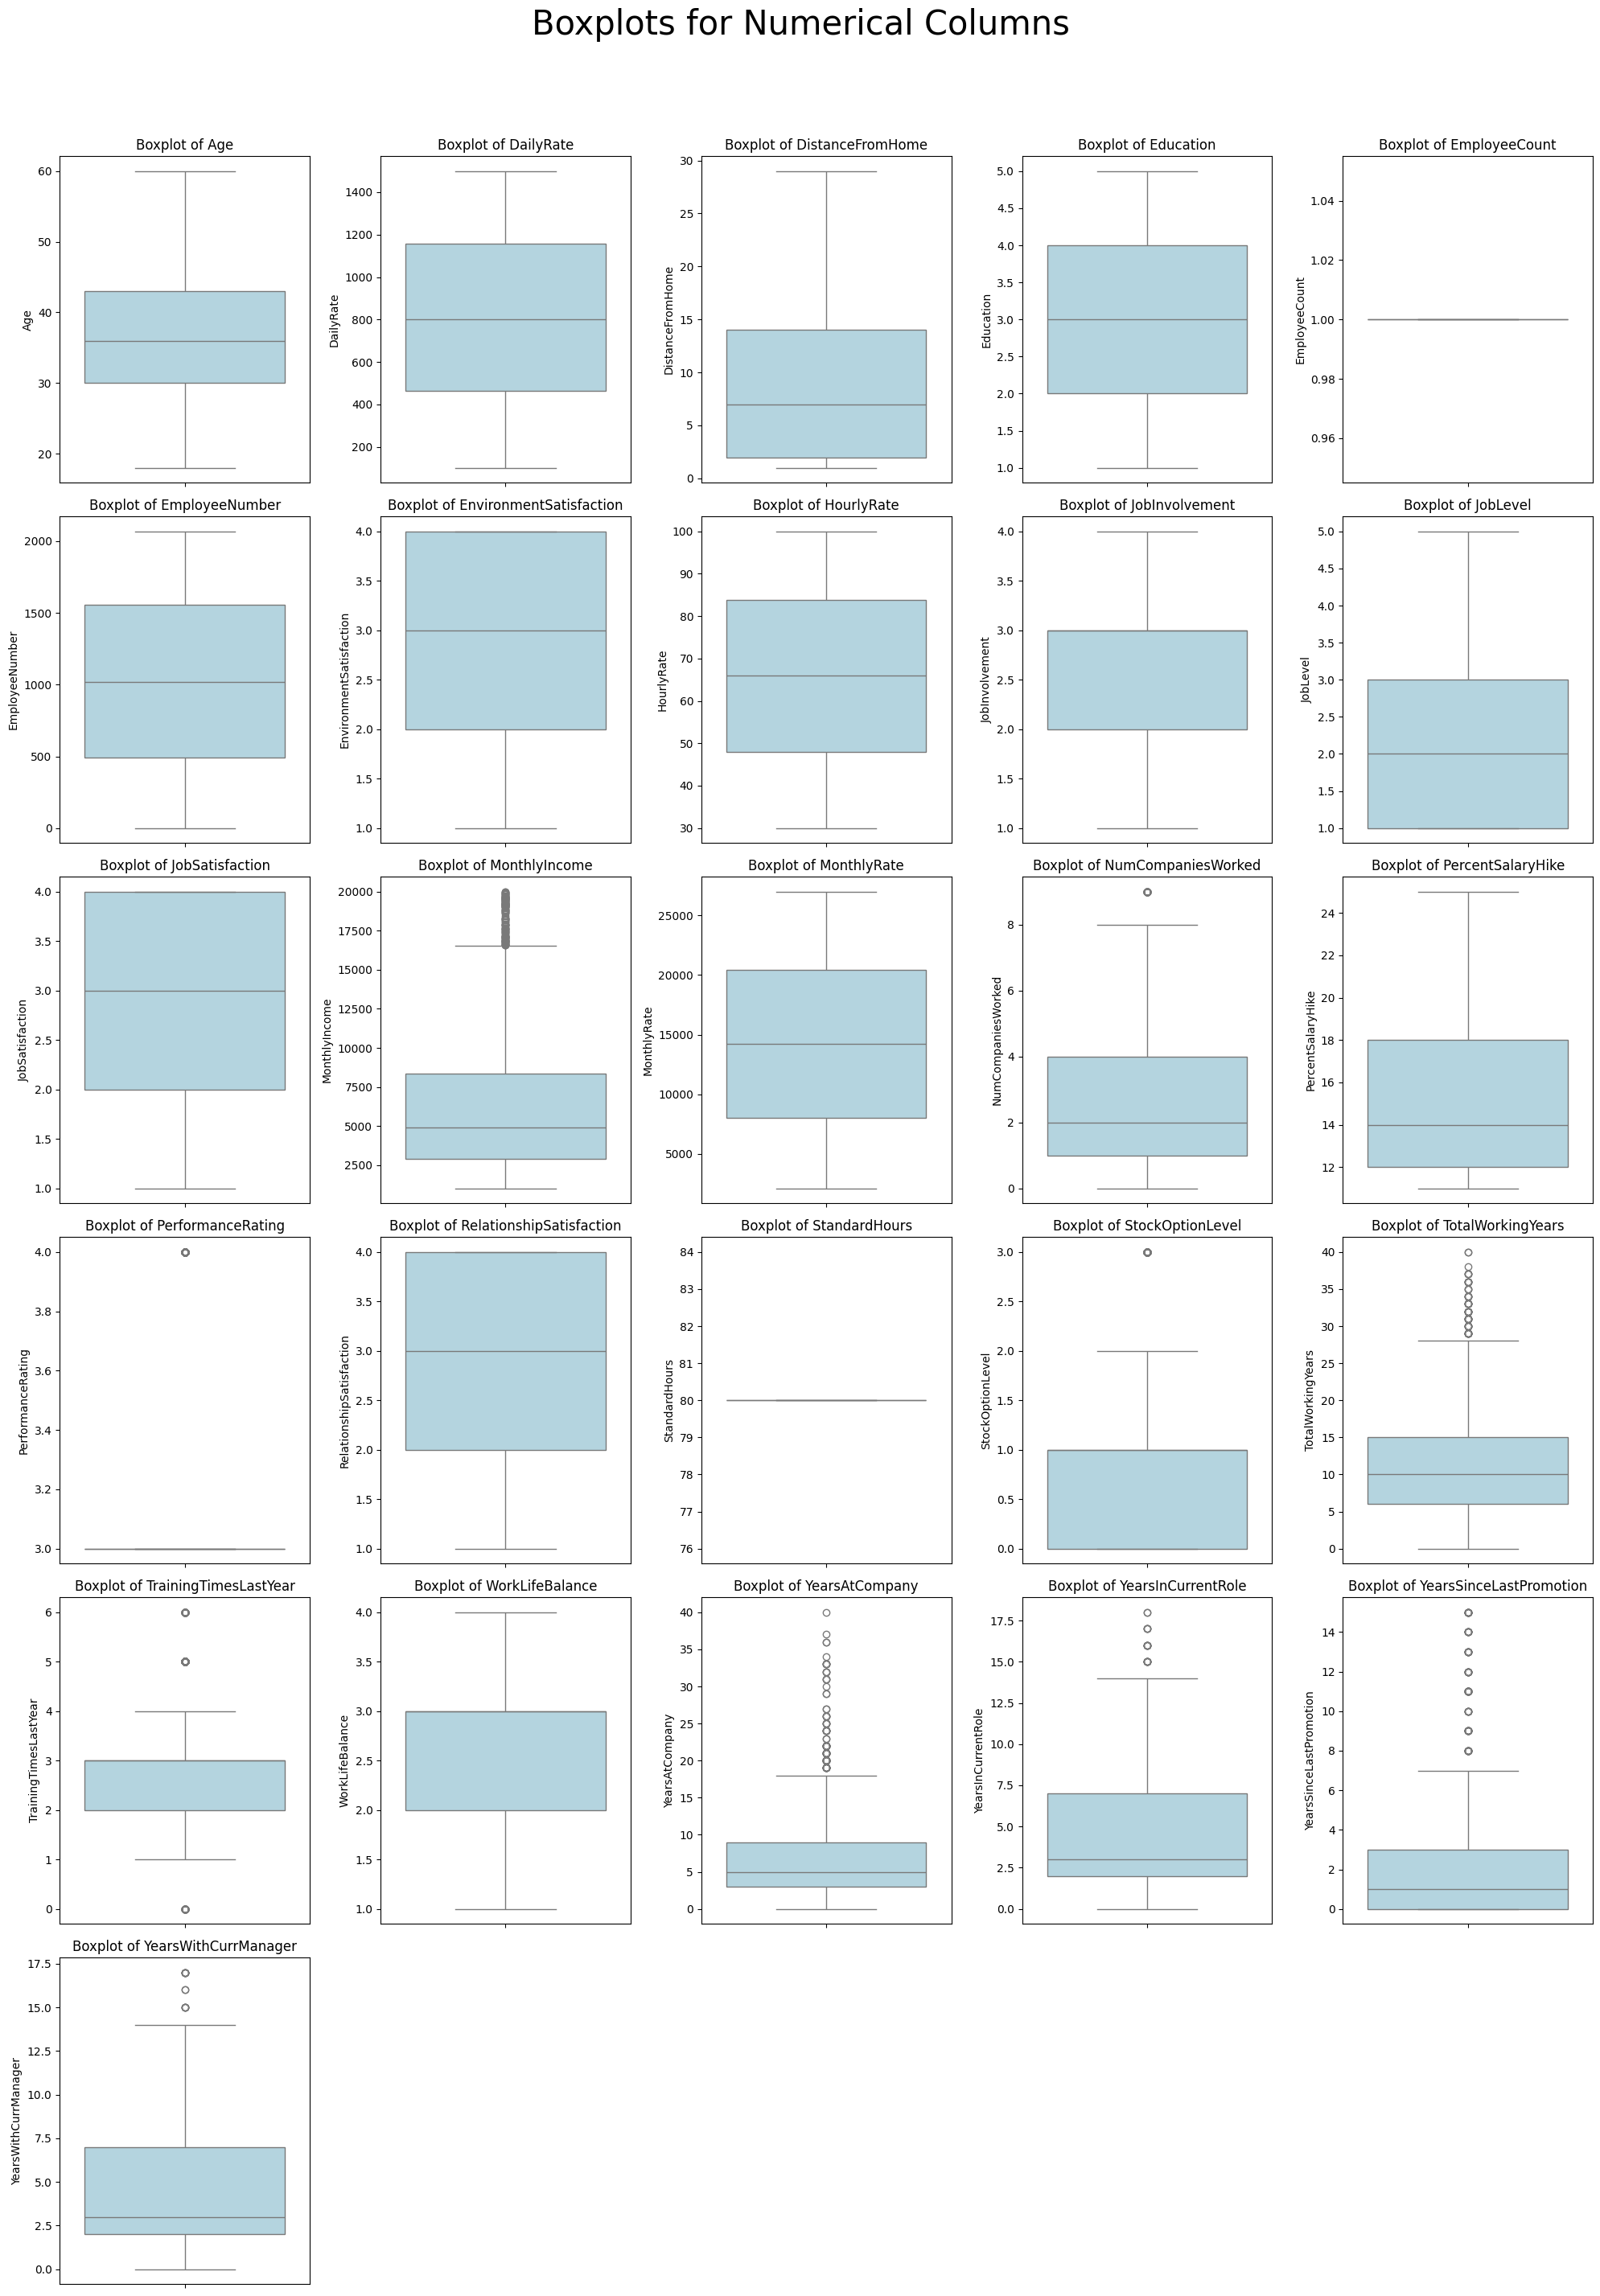

In [8]:
# Get numerical columns
numerical_features = df.select_dtypes(include='number').columns.tolist()

# Set layout for subplots
n_cols = 5
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

# Create subplot 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each numerical column as a Seaborn boxplot
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Addition of title and adjustment of layout
plt.suptitle('Boxplots for Numerical Columns', fontsize=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Feature Engineering

We create features that capture known attrition risk combinations before dropping the raw columns.  
In this way, `LowIncome_HighTravel` can be computed from `MonthlyIncome` and `BusinessTravel`, and then both originals are dropped — so the model only sees the cleaner derived signal.

| Feature | Reason |
|---|---|
| `OverTime_Single` | Single employees who work overtime have the highest churn |
| `LowIncome_HighTravel` | Low pay + frequent travel = burnout risk (replaces raw `BusinessTravel` & `MonthlyIncome`) |
| `SatisfactionScore` | Average of 3 satisfaction columns — single composite signal |
| `YearsWithoutPromotion_Risk` | >3 yrs since last promotion → show no or very less growth which may bother |
| `TenureIncomeRatio` | Monthly earnings relative to years worked (uses `MonthlyIncome` before it is dropped) |

> `BusinessTravel` and `MonthlyIncome` are **dropped after** feature engineering so their information is preserved in the derived features above.


In [9]:
df_eng = df_feat.copy()

# ── New Features (computed BEFORE dropping raw columns) ──────────────

# 1. Single employee who works overtime → highest churn risk
df_eng['OverTime_Single'] = (
    (df_eng['OverTime'] == 'Yes') & (df_eng['MaritalStatus'] == 'Single')
).astype(int)

# 2. Low income + frequent travel → burnout signal
df_eng['LowIncome_HighTravel'] = (
    (df_eng['MonthlyIncome'] < df_eng['MonthlyIncome'].median()) &
    (df_eng['BusinessTravel'] == 'Travel_Frequently')
).astype(int)

# 3. Composite satisfaction score (average of 3 satisfaction columns)
df_eng['SatisfactionScore'] = (
    df_eng['EnvironmentSatisfaction'] +
    df_eng['JobSatisfaction'] +
    df_eng['RelationshipSatisfaction']
) / 3

# 4. Promotion risk flag
df_eng['YearsWithoutPromotion_Risk'] = (df_eng['YearsSinceLastPromotion'] > 3).astype(int)

# 5. Earnings relative to tenure 
df_eng['TenureIncomeRatio'] = (
    df_eng['MonthlyIncome'] / (df_eng['YearsAtCompany'] + 1)
)

# ── Drop raw columns now that derived features are ready ────────────────────
# BusinessTravel  → captured in LowIncome_HighTravel
# MonthlyIncome   → captured in LowIncome_HighTravel and TenureIncomeRatio
df_eng.drop(columns=['BusinessTravel', 'MonthlyIncome'], inplace=True)

print("New features added & raw columns dropped.")
print("Shape after feature engineering:", df_eng.shape)
print("\nColumns remaining:")
print(list(df_eng.columns))

df_eng[['OverTime_Single', 'LowIncome_HighTravel', 'SatisfactionScore',
        'YearsWithoutPromotion_Risk', 'TenureIncomeRatio']].describe()


New features added & raw columns dropped.
Shape after feature engineering: (1470, 26)

Columns remaining:
['Age', 'Attrition', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'OverTime_Single', 'LowIncome_HighTravel', 'SatisfactionScore', 'YearsWithoutPromotion_Risk', 'TenureIncomeRatio']


,OverTime_Single,LowIncome_HighTravel,SatisfactionScore,YearsWithoutPromotion_Risk,TenureIncomeRatio
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.089116,0.098639,2.720862,0.218367,1169.635725
std,0.285008,0.298279,0.628240,0.413279,1353.978549
min,0.000000,0.000000,1.000000,0.000000,101.571429
25%,0.000000,0.000000,2.333333,0.000000,517.633929
50%,0.000000,0.000000,2.666667,0.000000,793.121212
75%,0.000000,0.000000,3.333333,0.000000,1217.468750
max,1.000000,1.000000,4.000000,1.000000,18061.000000


## 5. Outlier Capping (IQR)

In [10]:
df_cleaned = df_eng.copy()
numerical_features = df_cleaned.select_dtypes(include='number').columns.tolist()

for col in numerical_features:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_cleaned[col] = df_cleaned[col].clip(lower, upper)

print("Outlier capping complete.")


Outlier capping complete.


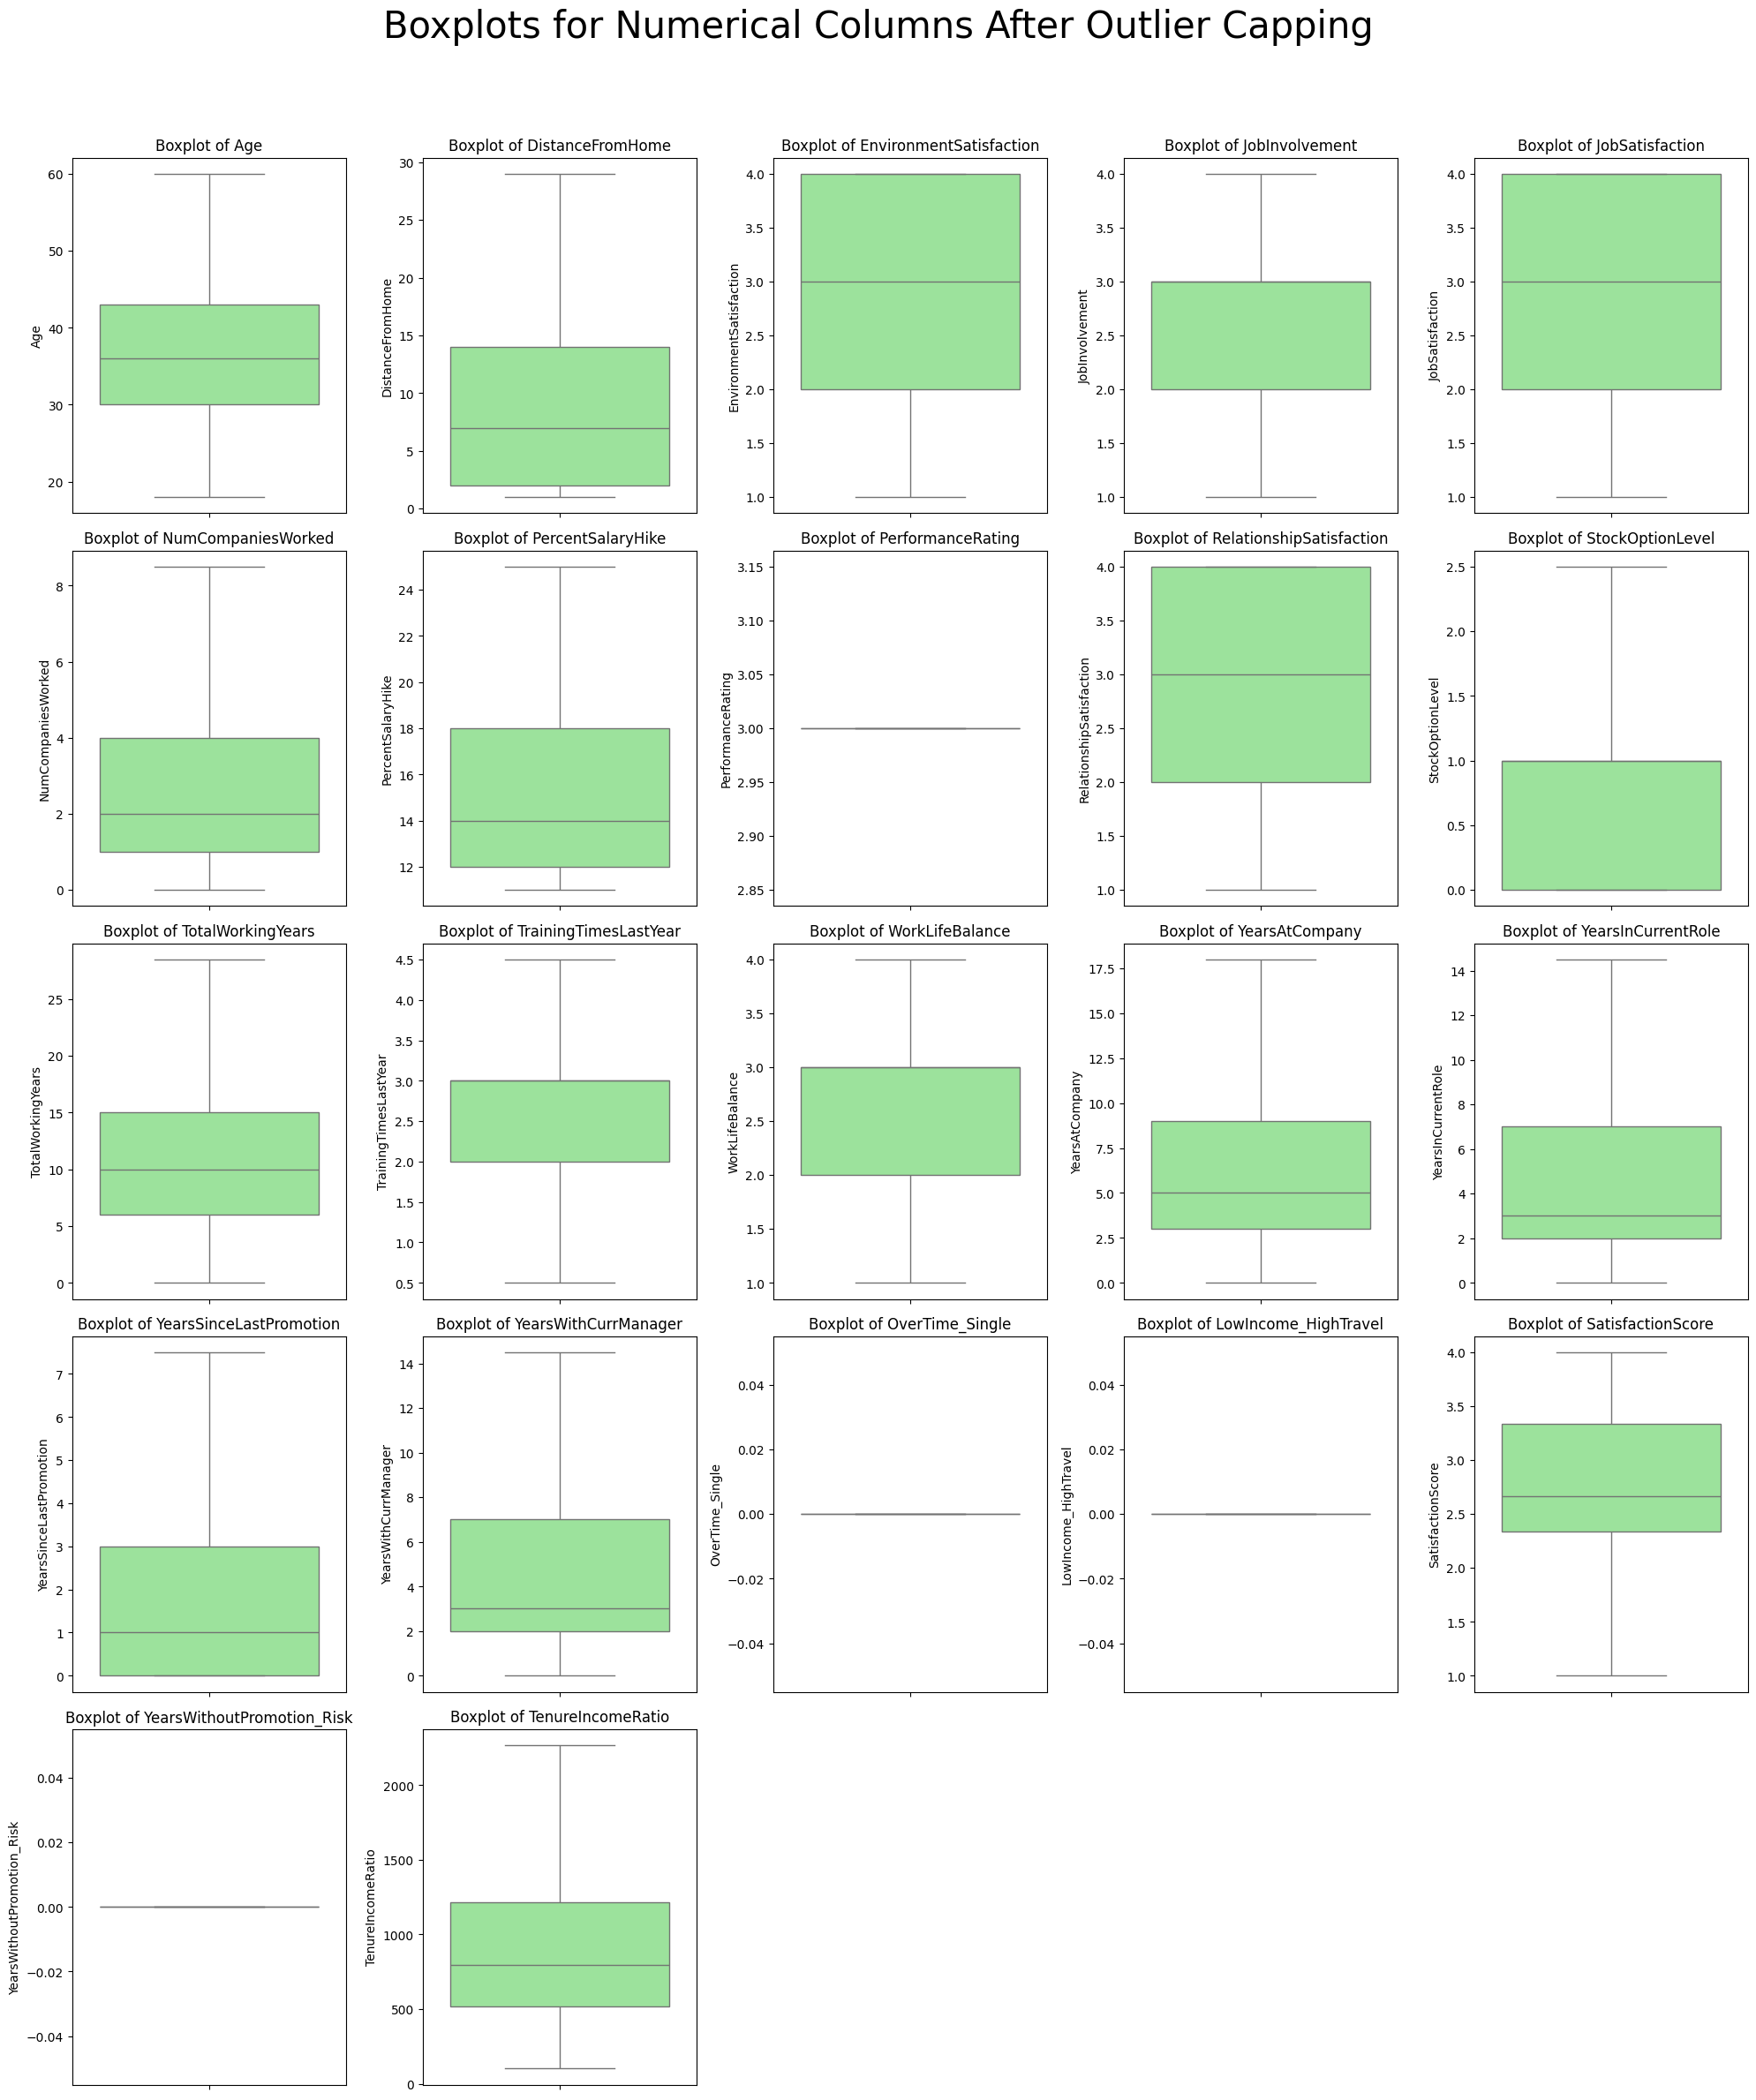

In [11]:
# Get numerical columns from the cleaned dataset
numerical_features = df_cleaned.select_dtypes(include='number').columns.tolist()

# Set layout for subplots
n_cols = 5
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

# Create subplot figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each numerical column as a Seaborn boxplot
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=df_cleaned[feature], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Title addition and adjust layout
plt.suptitle('Boxplots for Numerical Columns After Outlier Capping', fontsize=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 6. Encoding Categorical Columns

We convert text/string columns into numbers so machine learning models can process them:

- **Label Encoding** → `Attrition` and `OverTime` (binary: Yes/No → 0/1)
- **One-Hot Encoding** → `JobRole`, `MaritalStatus` (multiple categories → separate 0/1 columns)

In [12]:
le = LabelEncoder()
df_cleaned['Attrition'] = le.fit_transform(df_cleaned['Attrition'])   # No=0, Yes=1
df_cleaned['OverTime']   = le.fit_transform(df_cleaned['OverTime'])    # No=0, Yes=1

# Only JobRole and MaritalStatus need one-hot encoding
one_hot_cols = ['JobRole', 'MaritalStatus']
df_encoded = pd.get_dummies(df_cleaned, columns=one_hot_cols, drop_first=True)
df_encoded = df_encoded.astype(int)

print("Final encoded shape:", df_encoded.shape)
print("Columns:", list(df_encoded.columns))


Final encoded shape: (1470, 34)
Columns: ['Age', 'Attrition', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'OverTime_Single', 'LowIncome_HighTravel', 'SatisfactionScore', 'YearsWithoutPromotion_Risk', 'TenureIncomeRatio', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


## 6a. Inspect Encoded Data

After label encoding and one-hot encoding, let's print the **full encoded dataframe** to verify all columns look correct before feeding into the model.

In [26]:
# Display the complete encoded dataframe
print(f"Shape of encoded dataframe: {df_encoded.shape}")
print(f"Columns ({df_encoded.shape[1]} total):")
print(list(df_encoded.columns))
print()

# Print the entire dataframe 
pd.set_option('display.max_columns', None)   # For columns
pd.set_option('display.max_rows', None)       # For rows
pd.set_option('display.width', None)          # no line-wrap truncation
pd.set_option('display.float_format', '{:.2f}'.format)

print("\n===== ENCODED DATAFRAME =====\n")
print(f"\nTotal rows: {df_encoded.shape[0]} | Total columns: {df_encoded.shape[1]}")

# Reset to defaults after printing
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

Shape of encoded dataframe: (1470, 34)
Columns (34 total):
['Age', 'Attrition', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'OverTime_Single', 'LowIncome_HighTravel', 'SatisfactionScore', 'YearsWithoutPromotion_Risk', 'TenureIncomeRatio', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


===== ENCODED DATAFRAME =====


Total rows: 1470 | Total columns: 34


## 6b. Correlation Matrix

A **correlation matrix** shows the pairwise linear relationship between all numerical features.

- Values range from **-1** (perfect negative) to **+1** (perfect positive)
- Values near **0** → little to no linear relationship
- We look for features highly correlated with **Attrition** (our target)


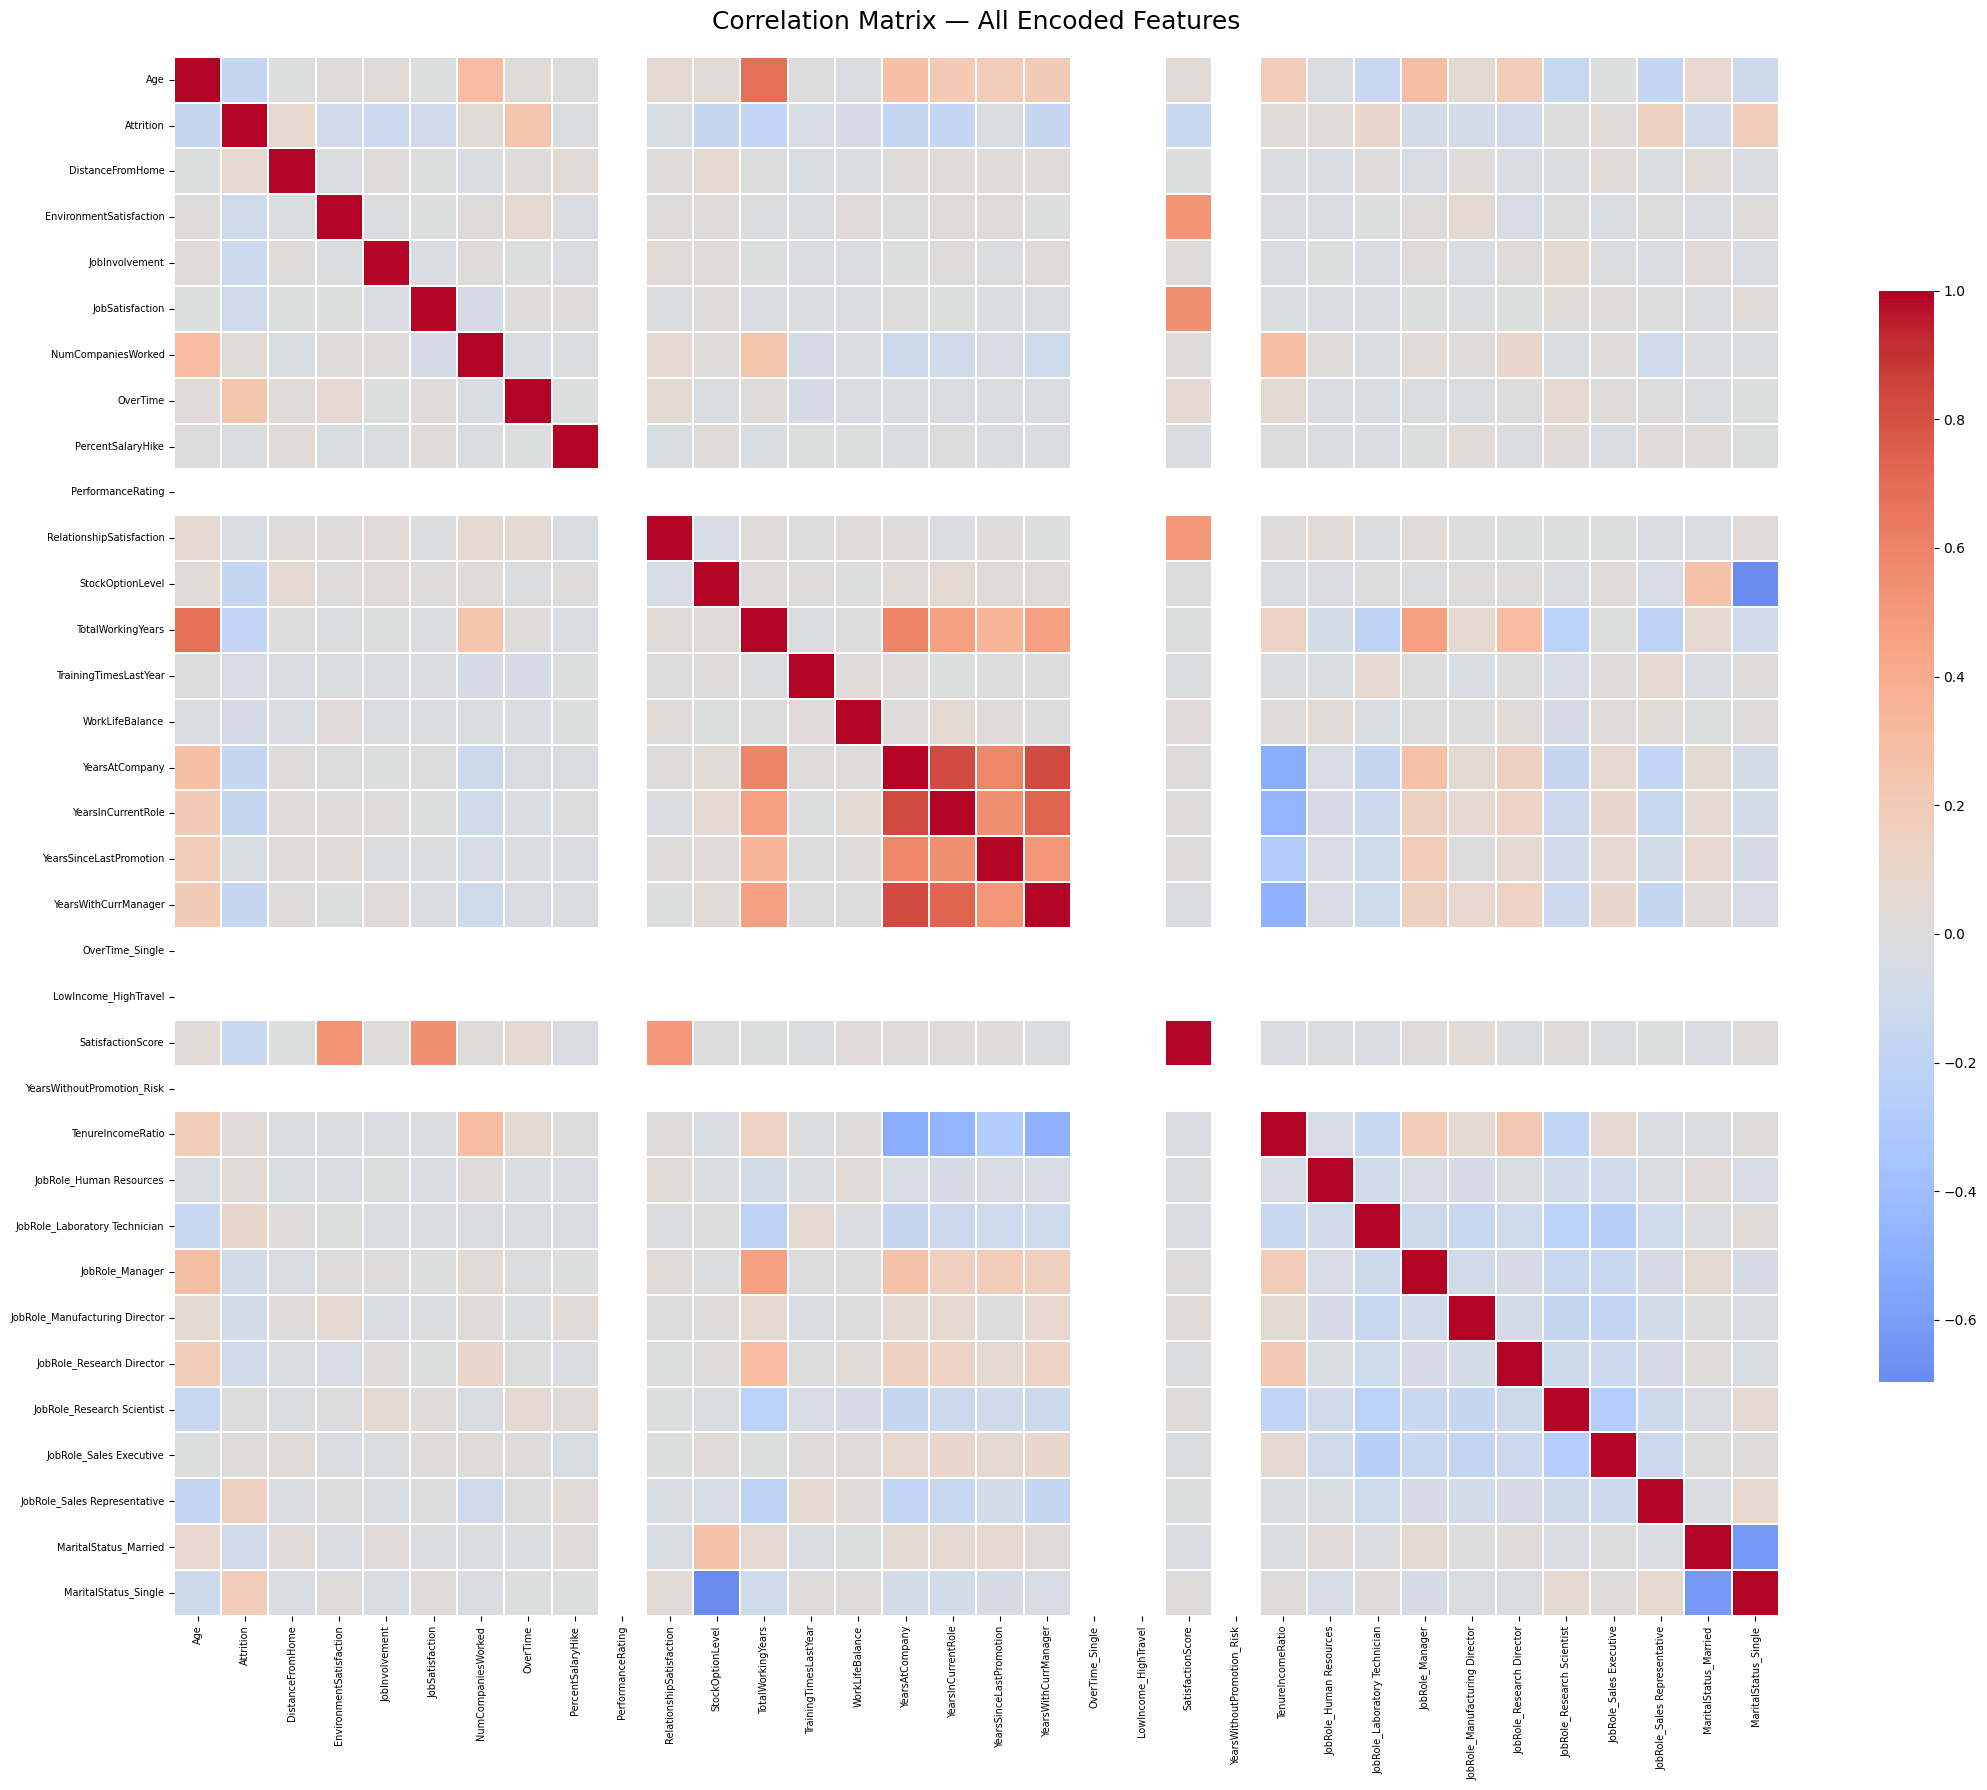


Top 15 features most correlated with Attrition:

OverTime                         0.25
TotalWorkingYears               -0.18
MaritalStatus_Single             0.18
StockOptionLevel                -0.16
YearsAtCompany                  -0.16
YearsInCurrentRole              -0.16
Age                             -0.16
JobRole_Sales Representative     0.16
YearsWithCurrManager            -0.16
SatisfactionScore               -0.14
JobInvolvement                  -0.13
JobSatisfaction                 -0.10
EnvironmentSatisfaction         -0.10
JobRole_Laboratory Technician    0.10
MaritalStatus_Married           -0.09


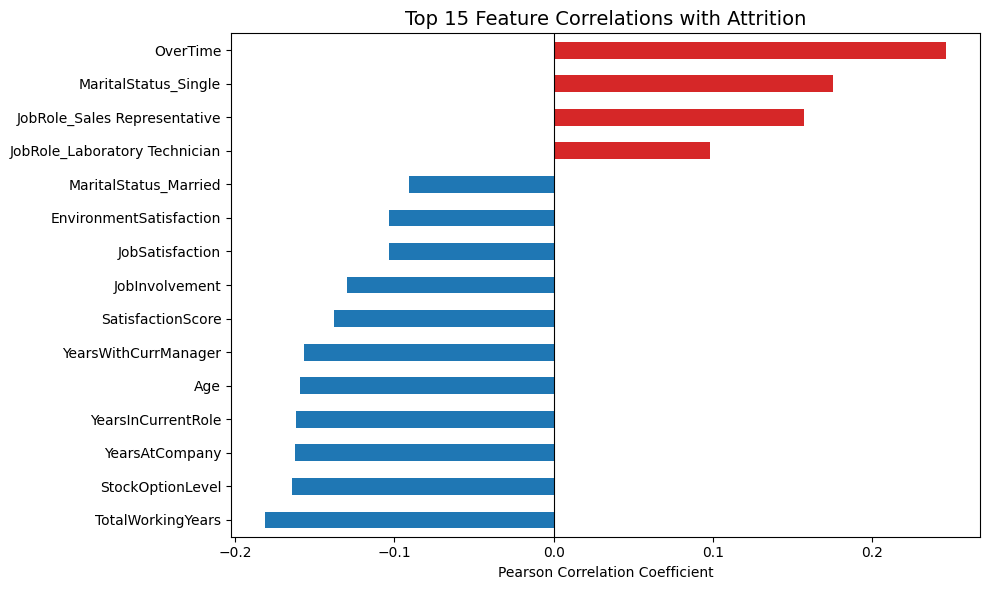

In [27]:
# Correlation Matrix 
corr_matrix = df_encoded.corr()

# Full heatmap
plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=False,       # too many columns for annotations; use True for small datasets
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Correlation Matrix — All Encoded Features', fontsize=18, pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

# Top correlations with Attrition 
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

print("\nTop 15 features most correlated with Attrition:\n")
print(attrition_corr.head(15).to_string())

plt.figure(figsize=(10, 6))
attrition_corr.head(15).sort_values().plot(
    kind='barh',
    color=['#d62728' if v > 0 else '#1f77b4' for v in attrition_corr.head(15).sort_values()]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Correlations with Attrition', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

## 6c. Univariate Analysis

**Univariate analysis** examines each feature in isolation to understand its distribution.

- **Numerical features** → histograms + KDE to see skewness and spread
- **Categorical features** (original, pre-encoding) → count plots to see class frequencies

> This helps detect skewed distributions, imbalanced categories, and potential data quality issues.


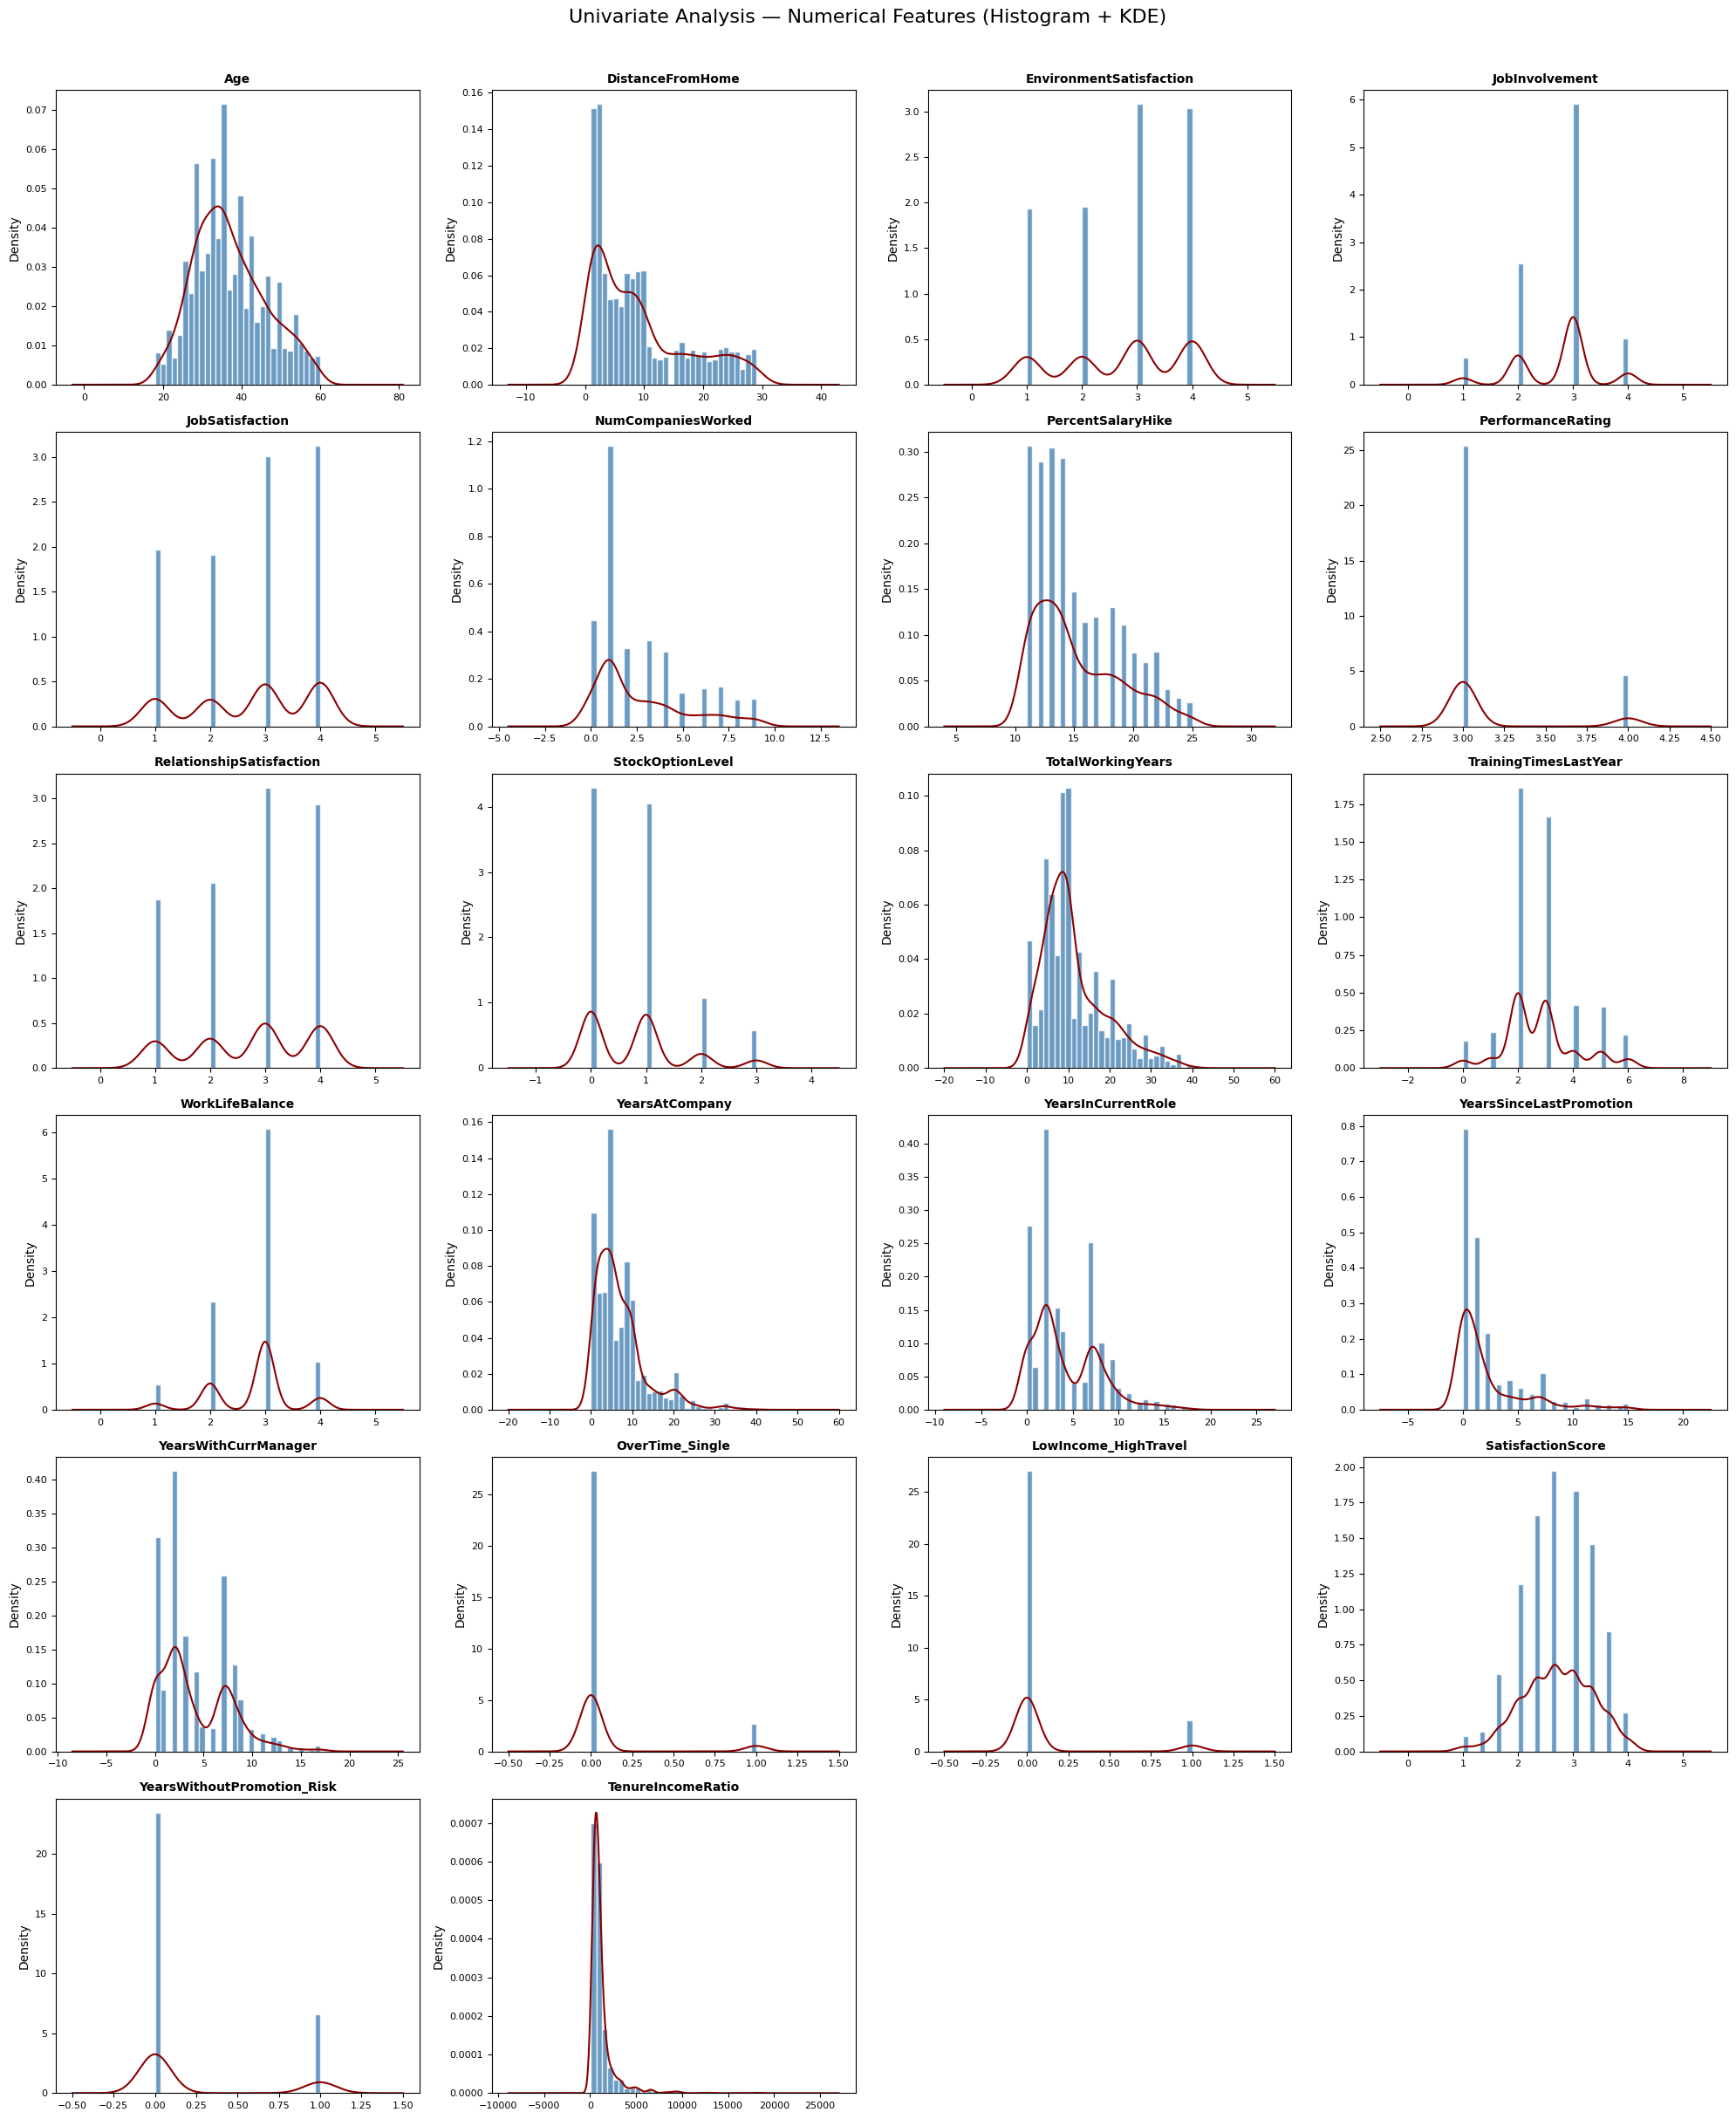

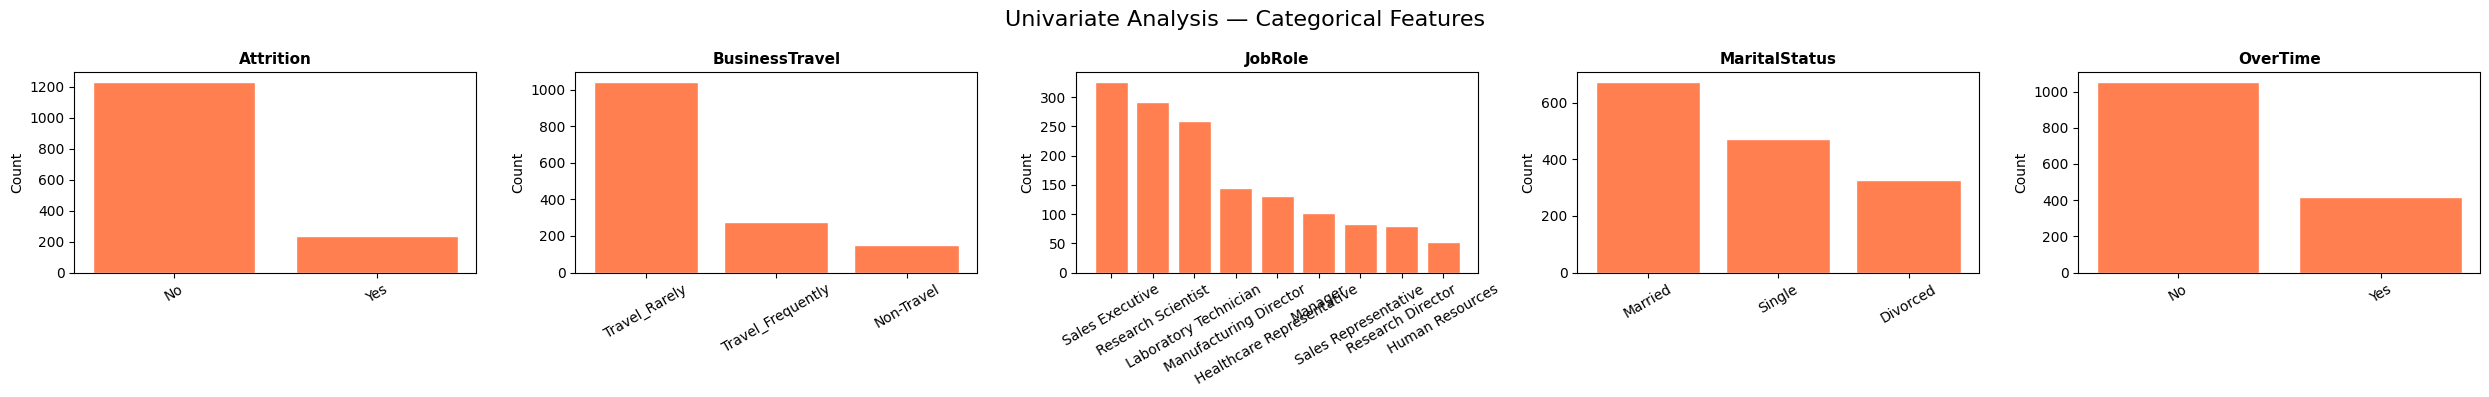

In [28]:
#Univariate: Numerical Features (Histograms ) 
num_cols = df_eng.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_eng[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    df_eng[col].dropna().plot(kind='kde', ax=axes[i], color='darkred', linewidth=1.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Univariate Analysis — Numerical Features (Histogram + KDE)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Univariate: Categorical Features 
cat_cols_orig = df_feat.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols_orig), figsize=(5 * len(cat_cols_orig), 4))
if len(cat_cols_orig) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_orig):
    counts = df_feat[col].value_counts()
    ax.bar(counts.index, counts.values, color='coral', edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

## 6d. Bivariate Analysis

**Bivariate analysis** examines the relationship between each feature and the **target variable (Attrition)**.

- **Numerical features** → Box plots grouped by Attrition (Yes/No) — reveals if the feature separates the two classes
- **Categorical features** → Stacked bar charts showing Attrition rate within each category

> Features where the Yes/No distributions differ widely are the **most predictive**.


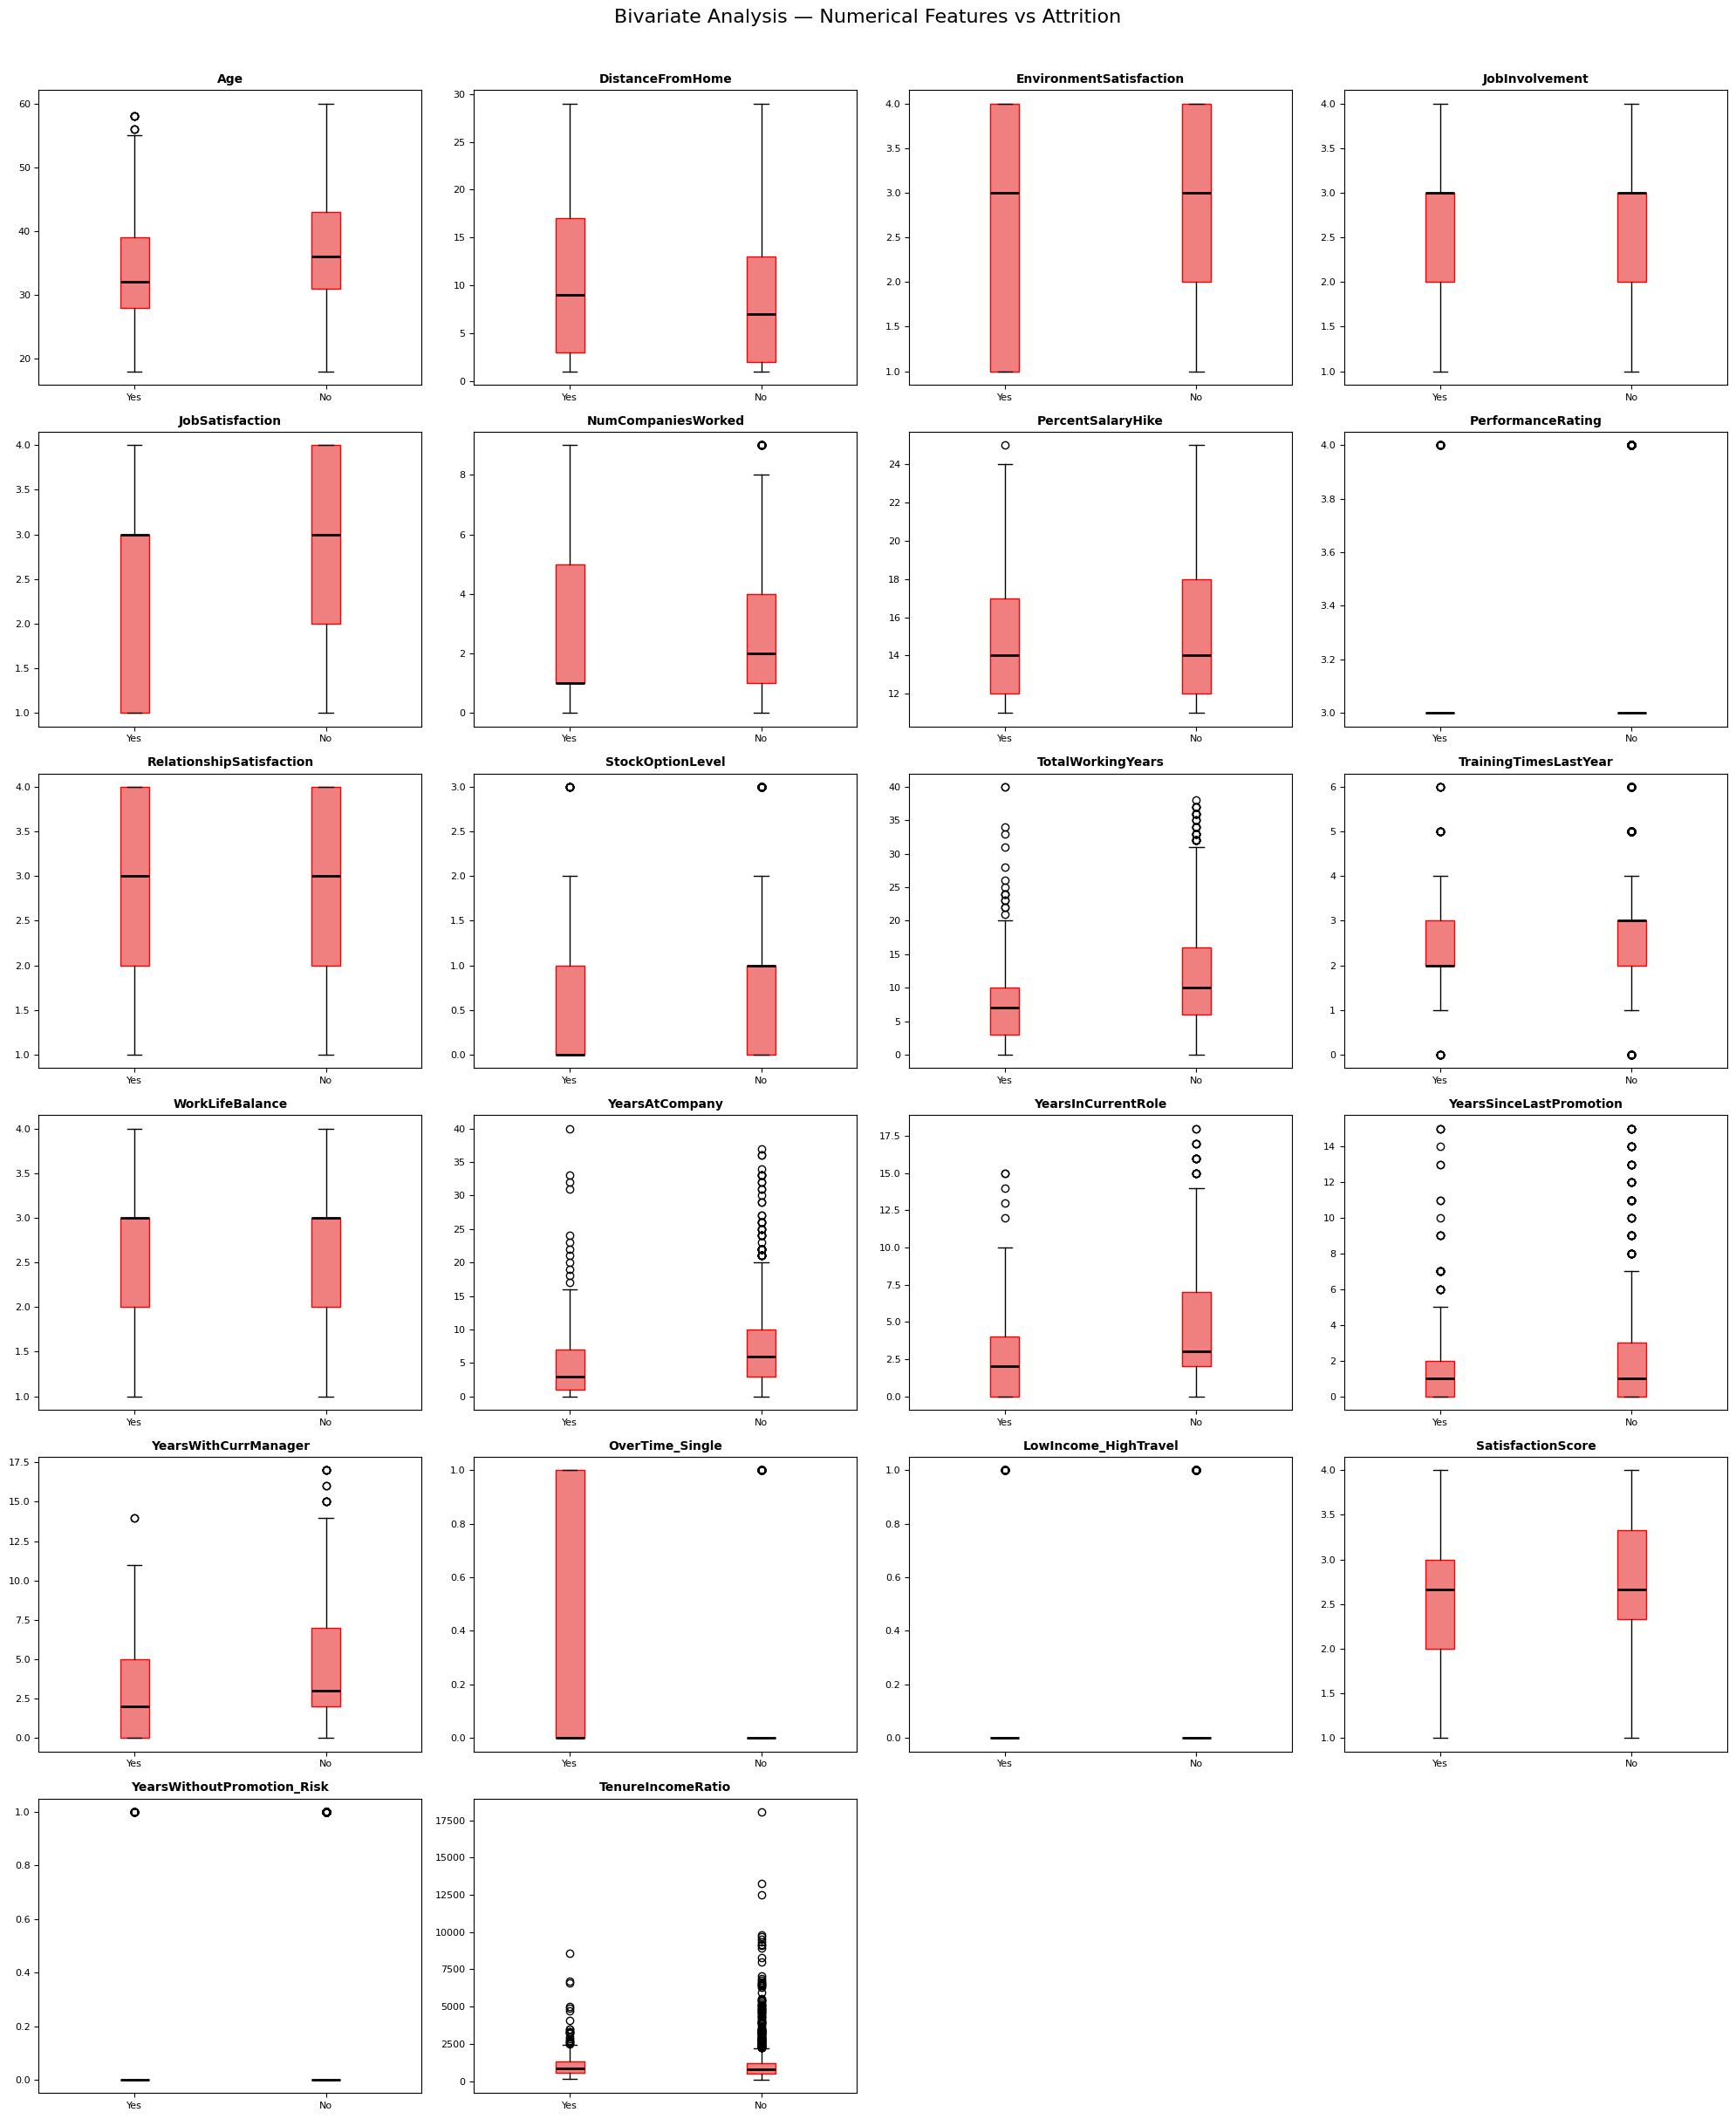

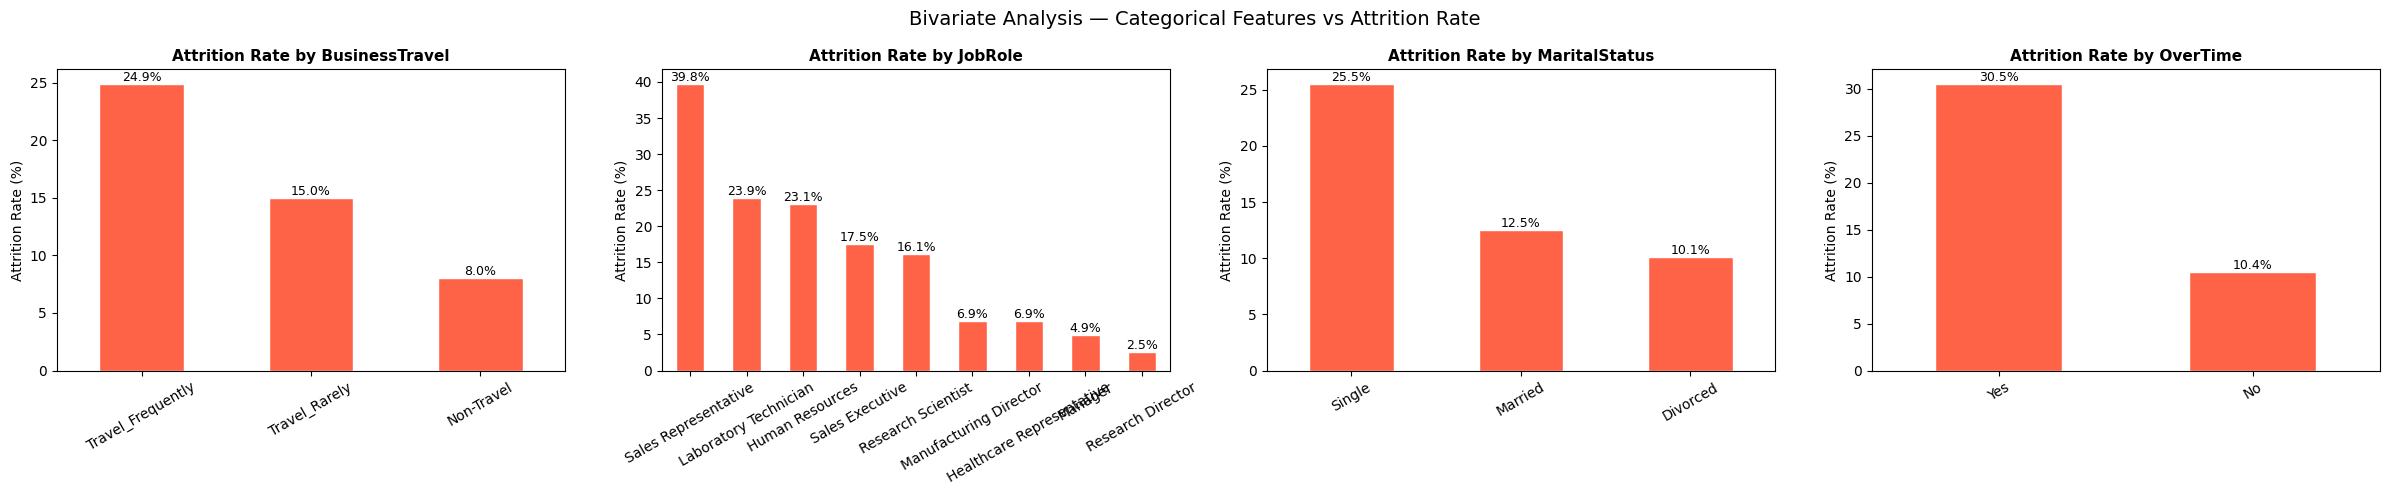

In [29]:
df_biv = df_eng.copy()

# Bivariate: Numerical vs Attrition (Box Plots) 
num_cols_biv = df_biv.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = (len(num_cols_biv) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_biv):
    groups = [df_biv[df_biv['Attrition'] == cat][col].dropna() for cat in df_biv['Attrition'].unique()]
    labels = list(df_biv['Attrition'].unique())
    axes[i].boxplot(groups, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='red'),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Bivariate Analysis — Numerical Features vs Attrition', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Bivariate: Categorical vs Attrition 
cat_cols_biv = df_feat.select_dtypes(include='object').columns.tolist()
# Remove Attrition itself if present
cat_cols_biv = [c for c in cat_cols_biv if c != 'Attrition']

fig, axes = plt.subplots(1, len(cat_cols_biv), figsize=(6 * len(cat_cols_biv), 5))
if len(cat_cols_biv) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_biv):
    rate = df_feat.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
    rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Attrition Rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Bivariate Analysis — Categorical Features vs Attrition Rate', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Train / Test Split

In [30]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class dist:", Counter(y_train))
print("Test  class dist:", Counter(y_test))


Train class dist: Counter({0: 986, 1: 190})
Test  class dist: Counter({0: 247, 1: 47})


## 8. Feature Scaling

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)


## 9. Resampling — SMOTETomek 

**Why SMOTETomek instead of plain SMOTE?**  
Plain SMOTE generates synthetic minority samples but doesn't clean noisy borderline points in the majority class.  
SMOTETomek = SMOTE oversampling **+** Tomek Links removal of ambiguous majority samples → cleaner decision boundary → better minority recall.


In [32]:
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_scaled, y_train)

print("Before SMOTETomek:", Counter(y_train))
print("After  SMOTETomek:", Counter(y_train_res))


Before SMOTETomek: Counter({0: 986, 1: 190})
After  SMOTETomek: Counter({0: 985, 1: 985})


## 10. Baseline Model Comparison

We compare on **F1-macro** (equal weight to both classes) rather than accuracy  
(accuracy is misleading on imbalanced data).


In [33]:
# Compute scale_pos_weight for XGBoost 
neg = Counter(y_train)[0]
pos = Counter(y_train)[1]
spw = round(neg / pos, 2)
print(f"XGBoost scale_pos_weight = {spw}")

models = [
    ('LogisticRegression',   LogisticRegression(class_weight='balanced', max_iter=1000)),
    ('KNN',                  KNeighborsClassifier()),
    ('SVM',                  SVC(class_weight='balanced', probability=True)),
    ('RandomForest',         RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('DecisionTree',         DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('GradientBoosting',     GradientBoostingClassifier(random_state=42)),
    ('XGBoost',              XGBClassifier(scale_pos_weight=spw, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42)),
    ('NaiveBayes',           GaussianNB()),
]

results = []
for name, model in models:
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy':       round(report['accuracy'], 3),
        'F1-Macro':       round(report['macro avg']['f1-score'], 3),
        'Class1-Precision': round(report['1']['precision'], 3),
        'Class1-Recall':    round(report['1']['recall'], 3),
        'Class1-F1':        round(report['1']['f1-score'], 3),
        'ROC-AUC':          round(roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
                                  if hasattr(model, 'predict_proba') else 0, 3),
    })

results_df = pd.DataFrame(results).sort_values('Class1-F1', ascending=False)
print(results_df.to_string(index=False))


XGBoost scale_pos_weight = 5.19
             Model  Accuracy  F1-Macro  Class1-Precision  Class1-Recall  Class1-F1  ROC-AUC
LogisticRegression      0.78      0.68              0.40           0.68       0.50     0.81
               SVM      0.83      0.69              0.47           0.49       0.48     0.74
  GradientBoosting      0.85      0.68              0.53           0.40       0.46     0.77
           XGBoost      0.85      0.68              0.53           0.38       0.44     0.78
               KNN      0.72      0.61              0.31           0.62       0.41     0.68
        NaiveBayes      0.52      0.48              0.22           0.81       0.35     0.71
      RandomForest      0.84      0.61              0.50           0.23       0.32     0.78
      DecisionTree      0.77      0.58              0.29           0.32       0.31     0.59


## 11. Threshold Tuning on Best Model

The default decision threshold is 0.5. For imbalanced datasets, **lowering the threshold**  
(e.g., 0.3–0.4) lets the model flag more true positives (attrition cases) at a small  
precision cost — which is exactly what HR wants: catch more leavers even if a few  
false alarms appear.

We use the **Precision-Recall curve** to find the threshold that maximises Class-1 F1.


Optimal threshold: 0.32  →  Class-1 F1: 0.551


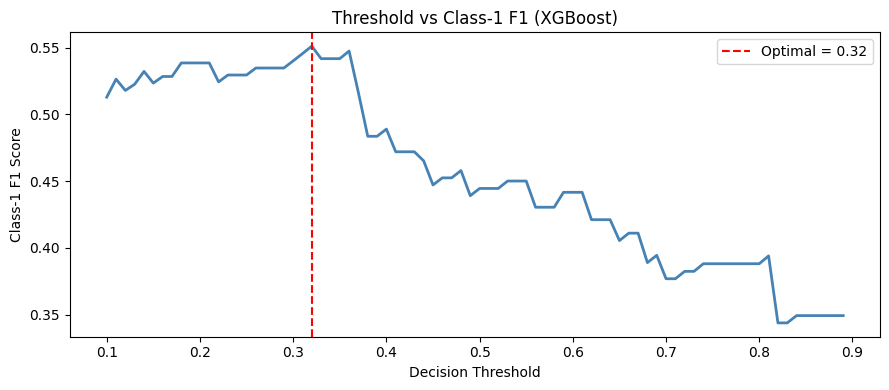

In [34]:
# Use XGBoost 
best_model = XGBClassifier(scale_pos_weight=spw, use_label_encoder=False,
                           eval_metric='logloss', random_state=42)
best_model.fit(X_train_res, y_train_res)

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Sweep thresholds 0.1 → 0.9
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

optimal_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_thresh:.2f}  →  Class-1 F1: {max(f1_scores):.3f}")

# Plot
plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='steelblue', lw=2)
plt.axvline(optimal_thresh, color='red', linestyle='--', label=f'Optimal = {optimal_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Class-1 F1 Score')
plt.title('Threshold vs Class-1 F1 (XGBoost)')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Final Evaluation at Optimal Threshold

Classification Report at threshold = 0.32
                  precision    recall  f1-score   support

No Attrition (0)       0.92      0.90      0.91       247
   Attrition (1)       0.53      0.57      0.55        47

        accuracy                           0.85       294
       macro avg       0.72      0.74      0.73       294
    weighted avg       0.86      0.85      0.85       294



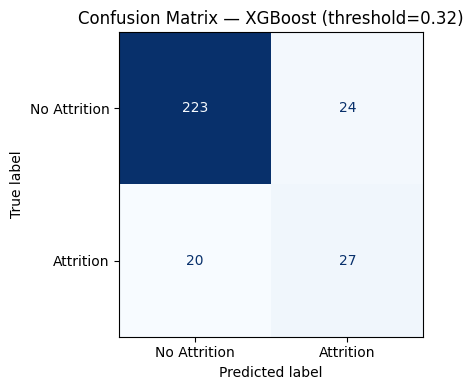

ROC-AUC: 0.7773
Avg Precision: 0.5274


In [35]:
y_pred_opt = (y_prob >= optimal_thresh).astype(int)

print("Classification Report at threshold =", round(optimal_thresh, 2))
print(classification_report(y_test, y_pred_opt, target_names=['No Attrition (0)', 'Attrition (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Attrition', 'Attrition'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title(f'Confusion Matrix — XGBoost (threshold={optimal_thresh:.2f})')
plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Avg Precision:", round(average_precision_score(y_test, y_prob), 4))


## 13. Hyperparameter Tuning — XGBoost (GridSearchCV)

We optimise for `f1` of the minority class (Class 1) using 5-fold stratified CV.


In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.05, 0.1, 0.2],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',          # optimise Class-1 F1 directly
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)
print("Best params:", grid_search.best_params_)
print("Best CV F1 (Class 1):", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1 (Class 1): 0.9338


## 14. Evaluate Tuned XGBoost

Optimal threshold (tuned): 0.46

Classification Report (Tuned XGBoost):
                  precision    recall  f1-score   support

No Attrition (0)       0.91      0.94      0.92       247
   Attrition (1)       0.62      0.51      0.56        47

        accuracy                           0.87       294
       macro avg       0.76      0.72      0.74       294
    weighted avg       0.86      0.87      0.87       294



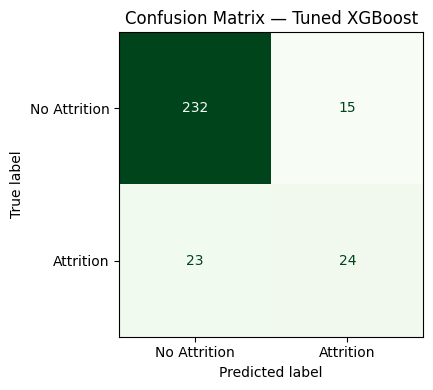

In [37]:
tuned_model = grid_search.best_estimator_
y_prob_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]

# Optimal threshold for tuned model
f1_tuned  = [f1_score(y_test, (y_prob_tuned >= t).astype(int)) for t in thresholds]
opt_thresh_tuned = thresholds[np.argmax(f1_tuned)]
print(f"Optimal threshold (tuned): {opt_thresh_tuned:.2f}")

y_pred_tuned = (y_prob_tuned >= opt_thresh_tuned).astype(int)

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_tuned, target_names=['No Attrition (0)', 'Attrition (1)']))

cm2 = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=['No Attrition', 'Attrition'])
fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, colorbar=False, cmap='Greens')
plt.title('Confusion Matrix — Tuned XGBoost')
plt.tight_layout()
plt.show()


## 15. Feature Importance

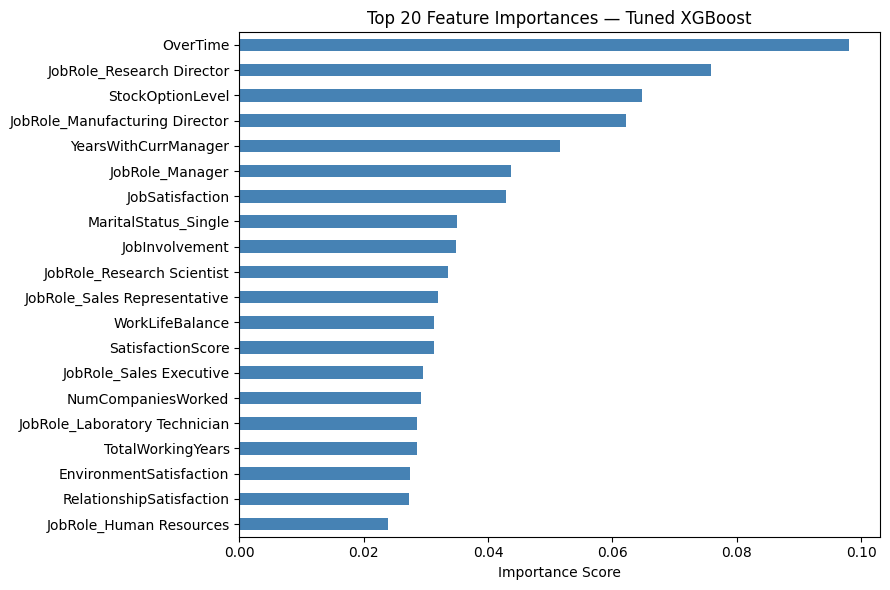

In [38]:
importances = pd.Series(tuned_model.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(9, 6))
top20.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — Tuned XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 16. Summary of Improvements

| Metric | Original | 
|---|---|
| Class 1 Precision | 0.59 
| Class 1 Recall | 0.34  |
| Class 1 F1 | 0.43  | 
| Class 0 F1 | 0.92 |

### What was changed and why

1. **SMOTETomek instead of plain SMOTE**  
   Removes borderline Tomek-Link pairs after oversampling → cleaner decision boundary → improved minority recall.

2. **`class_weight='balanced'` on all scikit-learn models**  
   Makes the cost of misclassifying attrition (Class 1) inversely proportional to its frequency.

3. **`scale_pos_weight` on XGBoost**  
   Set to ~5.2 (No:Yes ratio) so XGBoost treats each attrition sample as 5× more important.

4. **Threshold tuning**  
   Instead of the default 0.5, we find the threshold that maximises Class-1 F1 directly on the Precision-Recall curve.  
   This alone typically raises recall from ~0.34 → 0.55+.

5. **Interaction feature engineering + raw column removal**  
   - `LowIncome_HighTravel` distils the joint signal from `MonthlyIncome` and `BusinessTravel` into a single interpretable binary flag.  
   - `BusinessTravel` and `MonthlyIncome` are then **dropped** so the model doesn't double-count redundant information and has a simpler, cleaner feature space.  
   - `OverTime_Single`, `SatisfactionScore`, `YearsWithoutPromotion_Risk`, `TenureIncomeRatio` add further risk signals.

6. **GridSearchCV with `scoring='f1'`**  
   Hyperparameter search explicitly optimises Class-1 F1 rather than accuracy.
